In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Numerical differentiation

In [2]:
def central_numerical_differentiation(y, t):
    y = np.asarray(y)
    t = np.asarray(t)
    dy = np.zeros(len(y)) 

    dy[1:-1] = (y[2:] - y[:-2]) / (t[2:] - t[:-2])

    
    dy[0] = (y[1] - y[0]) / (t[1] - t[0]) #forward
    dy[-1] = (y[-1] - y[-2]) / (t[-1] - t[-2]) #backward

    return dy 

## The Trapezoidal Rule (composite trapezoidal rule)

In [3]:
def composite_trapezoidal_rule(t, f):
    integral = np.zeros(len(f))

    for i in range(1, len(f)):
        h = t[i] - t[i-1]
        integral[i] = (integral[i-1] + (f[i-1] + f[i]) * h/2)

    return integral

In [4]:
def calculate_distance(x, y):
    dx = np.diff(x)
    dy = np.diff(y)

    ds = np.sqrt(dx**2 + dy**2)

    s = np.zeros(len(x))
    s[1:] = np.cumsum(ds)

    return s

In [5]:
df = pd.read_excel("dev2_combined_365bags_2025-02-23_07-10-45_2025-02-23_13-15-31_CET.xlsx")

In [6]:
data = df[["timestamp (1740291045,1740312931) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]", "angular_velocity (-60,60) [掳/s]", "angular_velocity_magnitude (0,60) [rad/s]"]].copy()

In [7]:
data = data.rename(columns={"timestamp (1740291045,1740312931) [unix]" : "timestamp",
                           "velocity (0,200) [km/h]" : "velocity",
                           "velocity_heading (0,360) [掳]" : "velocity_heading", 
                            "angular_velocity (-60,60) [掳/s]" : "angular_velocity", 
                            "angular_velocity_magnitude (0,60) [rad/s]" : "angular_velocity_magnitude"})

In [8]:
data["time"] = data["timestamp"] - data["timestamp"].iloc[0]
data["dt"] = data["timestamp"].diff()
print(data["dt"].describe())
print(data["dt"].value_counts().sort_index())

count    218373.000000
mean          0.100223
std           0.006473
min           0.100000
25%           0.100000
50%           0.100000
75%           0.100000
max           1.300000
Name: dt, dtype: float64
dt
0.1    130800
0.1     87207
0.2        72
0.2       222
0.3        27
0.3         8
0.4         7
0.4        27
0.5         2
1.3         1
Name: count, dtype: int64


In [9]:
data["SS"] = "" 
data.loc[65499:67978, "SS"] = "SS1" 
data.loc[69685:73097, "SS"] = "SS2" 
data.loc[190521:194040, "SS"] = "SS3" 
data.loc[198312:200644, "SS"] = "SS4" 

ss1 = data[data["SS"] == "SS1"].copy() 
ss2 = data[data["SS"] == "SS2"].copy() 
ss3 = data[data["SS"] == "SS3"].copy() 
ss4 = data[data["SS"] == "SS4"].copy()

# Vehicle1

In [10]:
ss1 = ss1.loc[65499:67772].copy()

In [11]:
trajectory_ss1 = pd.read_csv("vehicle1_SS1_trajectory.csv")

## Special Stage 1

In [12]:
print(ss1["dt"].describe())
print(ss1["dt"].round(1).value_counts().sort_index())

count    2274.000000
mean        0.100176
std         0.004191
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max         0.200000
Name: dt, dtype: float64
dt
0.1    2270
0.2       4
Name: count, dtype: int64


In [13]:
trajectory_ss1_cut = trajectory_ss1.iloc[:len(ss1)].copy()

ss1["x"] = trajectory_ss1_cut["x"].to_numpy()
ss1["y"] = trajectory_ss1_cut["y"].to_numpy()

In [14]:
t = ss1["timestamp"].to_numpy()
x = ss1["x"].to_numpy()
y = ss1["y"].to_numpy()

In [15]:
ss1["dx_dt"] = central_numerical_differentiation(x, t)
ss1["dy_dt"] = central_numerical_differentiation(y, t)

In [16]:
ss1["velocity_num"] = np.sqrt(ss1["dx_dt"]**2 + ss1["dy_dt"]**2)

ss1["velocity"] = pd.to_numeric(ss1["velocity"], errors = "coerce")
print(ss1["velocity"].isna().sum())

ss1["velocity_ms"] = ss1["velocity"] / 3.6
ss1["velocity_error"] = (ss1["velocity_num"] - ss1["velocity_ms"])

0


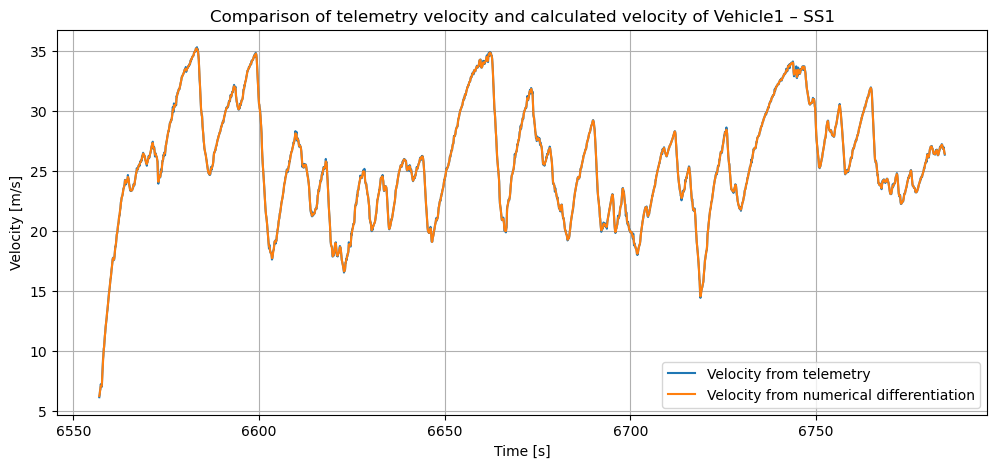

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(ss1["time"], ss1["velocity_ms"], label="Velocity from telemetry")
plt.plot(ss1["time"], ss1["velocity_num"], label="Velocity from numerical differentiation")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Comparison of telemetry velocity and calculated velocity of Vehicle1 – SS1")
plt.legend()
plt.grid()
plt.show()

In [18]:
ss1["dx2_dt2"] = central_numerical_differentiation(ss1["dx_dt"].to_numpy(), t)
ss1["dy2_dt2"] = central_numerical_differentiation(ss1["dy_dt"].to_numpy(), t)

### Curvature

In [19]:
ss1["curvature"] = ((ss1["dx_dt"] * ss1["dy2_dt2"]) - (ss1["dy_dt"] * ss1["dx2_dt2"])) / (ss1["dx_dt"]**2 + ss1["dy_dt"]**2)**(3/2)
ss1["curvature"].describe()

count    2274.000000
mean       -0.000639
std         0.006954
min        -0.046877
25%        -0.004218
50%        -0.000568
75%         0.002524
max         0.034158
Name: curvature, dtype: float64

In [20]:
ss1["abs_curvature"] = ss1["curvature"].abs()
ss1["abs_curvature"].describe()

count    2.274000e+03
mean     4.850416e-03
std      5.023333e-03
min      5.186031e-07
25%      1.389147e-03
50%      3.331258e-03
75%      6.771898e-03
max      4.687697e-02
Name: abs_curvature, dtype: float64

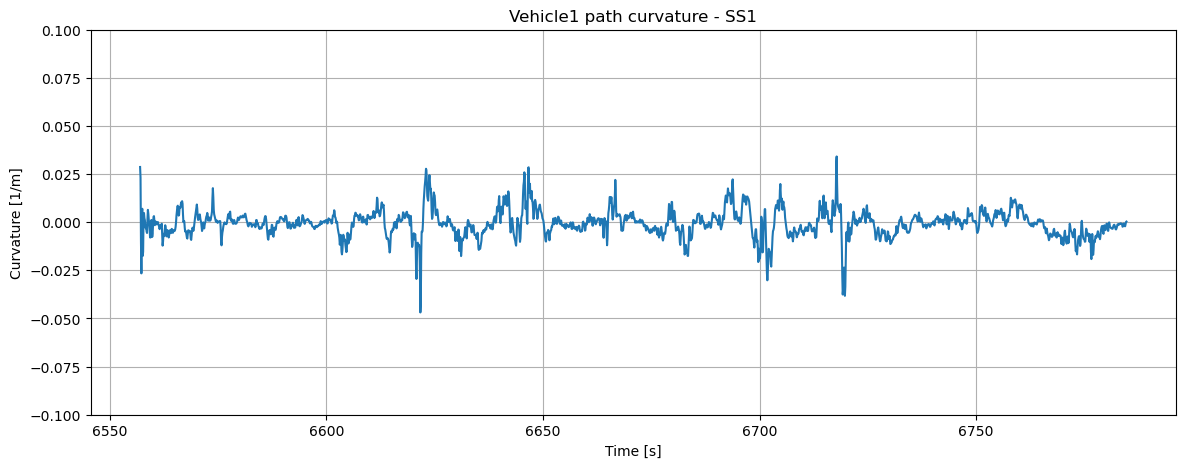

In [21]:
plt.figure(figsize = (14,5))
plt.plot(ss1["time"], ss1["curvature"])

plt.xlabel("Time [s]")
plt.ylabel("Curvature [1/m]")
plt.title("Vehicle1 path curvature - SS1")

plt.ylim(-0.10, 0.10)

plt.grid()
plt.show()

In [22]:
ss1["s"] = calculate_distance(ss1["x"].to_numpy(), ss1["y"].to_numpy())

# Vehicle2

In [23]:
df_2 = pd.read_excel("dev_3_combined_447bags_2025-02-23_07-06-09_2025-02-23_14-32-35_CET.xlsx")

In [24]:
data_2 = df_2[["timestamp (1740290769,1740317555) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]", "angular_velocity (-60,60) [掳/s]"]].copy()

In [25]:
data_2["time"] = data_2["timestamp (1740290769,1740317555) [unix]"] - data_2["timestamp (1740290769,1740317555) [unix]"].iloc[0]

In [26]:
ss1_v2 = data_2.loc[29133:31647].copy()

In [27]:
ss1_v2["dt"] = ss1_v2["timestamp (1740290769,1740317555) [unix]"].diff()

In [28]:
ss1_v2["velocity (0,200) [km/h]"] = pd.to_numeric(ss1_v2["velocity (0,200) [km/h]"], errors = "coerce")

In [29]:
"""
print(ss1_v2[[    
    "timestamp (1740290769,1740317555) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss1_v2[[    \n    "timestamp (1740290769,1740317555) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [30]:
ss1_v2["velocity (0,200) [km/h]"] = ss1_v2["velocity (0,200) [km/h]"].interpolate()
ss1_v2["velocity_heading (0,360) [掳]"] = ss1_v2["velocity_heading (0,360) [掳]"].interpolate()

In [31]:
ss1_v2["velocity [m/s]"] = ss1_v2["velocity (0,200) [km/h]"] / 3.6 
ss1_v2["velocity_heading (rad)"] = ss1_v2["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [32]:
psi_v2 = ss1_v2["velocity_heading (rad)"]
ss1_v2["v_x"] = ss1_v2["velocity [m/s]"] * np.sin(psi_v2)
ss1_v2["v_y"] = ss1_v2["velocity [m/s]"] * np.cos(psi_v2)

In [33]:
t_v2 = ss1_v2["timestamp (1740290769,1740317555) [unix]"].to_numpy()

ss1_v2["x"] = composite_trapezoidal_rule(t_v2, ss1_v2["v_x"].to_numpy())
ss1_v2["y"] = composite_trapezoidal_rule(t_v2, ss1_v2["v_y"].to_numpy())

## Geometric analysis and curvature - Vehicle2

In [34]:
ss1_v2 = ss1_v2.loc[29133:31251].copy()

In [35]:
print(ss1_v2["dt"].describe())
print(ss1_v2["dt"].round(1).value_counts().sort_index())

count    2118.000000
mean        0.100047
std         0.002173
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max         0.200000
Name: dt, dtype: float64
dt
0.1    2117
0.2       1
Name: count, dtype: int64


In [36]:
t = ss1_v2["timestamp (1740290769,1740317555) [unix]"].to_numpy()
x = ss1_v2["x"].to_numpy()
y = ss1_v2["y"].to_numpy()

In [37]:
ss1_v2["dx_dt"] = central_numerical_differentiation(x, t)
ss1_v2["dy_dt"] = central_numerical_differentiation(y, t)

In [38]:
ss1_v2["velocity_num"] = np.sqrt(ss1_v2["dx_dt"]**2 + ss1_v2["dy_dt"]**2)

ss1_v2["velocity (0,200) [km/h]"] = pd.to_numeric(ss1_v2["velocity (0,200) [km/h]"], errors = "coerce")
print(ss1_v2["velocity (0,200) [km/h]"].isna().sum())

ss1_v2["velocity_ms"] = ss1_v2["velocity (0,200) [km/h]"] / 3.6
ss1_v2["velocity_error"] = (ss1_v2["velocity_num"] - ss1_v2["velocity_ms"])

0


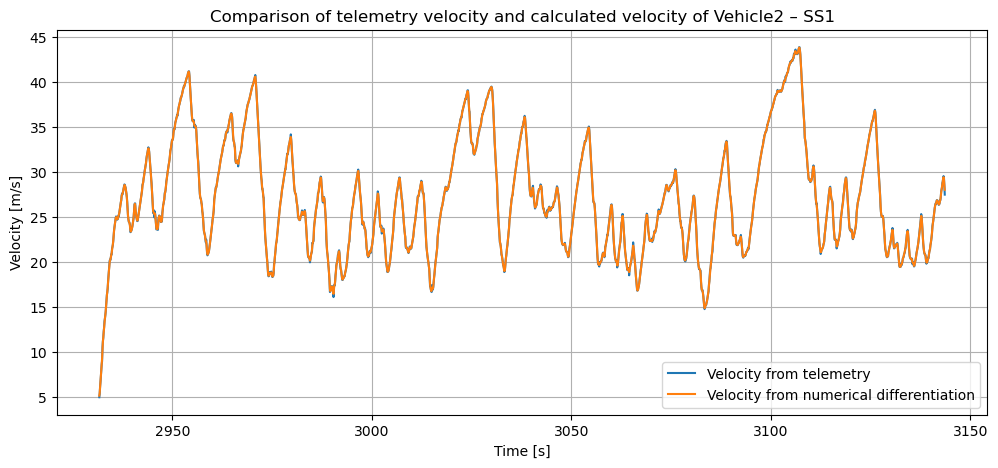

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(ss1_v2["time"], ss1_v2["velocity_ms"], label="Velocity from telemetry")
plt.plot(ss1_v2["time"], ss1_v2["velocity_num"], label="Velocity from numerical differentiation")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Comparison of telemetry velocity and calculated velocity of Vehicle2 – SS1")
plt.legend()
plt.grid()
plt.show()

In [40]:
ss1_v2["dx2_dt2"] = central_numerical_differentiation(ss1_v2["dx_dt"].to_numpy(), t)
ss1_v2["dy2_dt2"] = central_numerical_differentiation(ss1_v2["dy_dt"].to_numpy(), t)

In [41]:
ss1_v2["curvature"] = ((ss1_v2["dx_dt"] * ss1_v2["dy2_dt2"]) - (ss1_v2["dy_dt"] * ss1_v2["dx2_dt2"])) / (ss1_v2["dx_dt"]**2 + ss1_v2["dy_dt"]**2)**(3/2)
ss1_v2["curvature"].describe()

count    2119.000000
mean       -0.000637
std         0.007115
min        -0.056329
25%        -0.004503
50%        -0.000697
75%         0.002840
max         0.031347
Name: curvature, dtype: float64

In [42]:
ss1_v2["abs_curvature"] = ss1_v2["curvature"].abs()
ss1_v2["abs_curvature"].describe()

count    2.119000e+03
mean     5.186621e-03
std      4.910991e-03
min      8.111796e-09
25%      1.678185e-03
50%      3.736631e-03
75%      7.353434e-03
max      5.632864e-02
Name: abs_curvature, dtype: float64

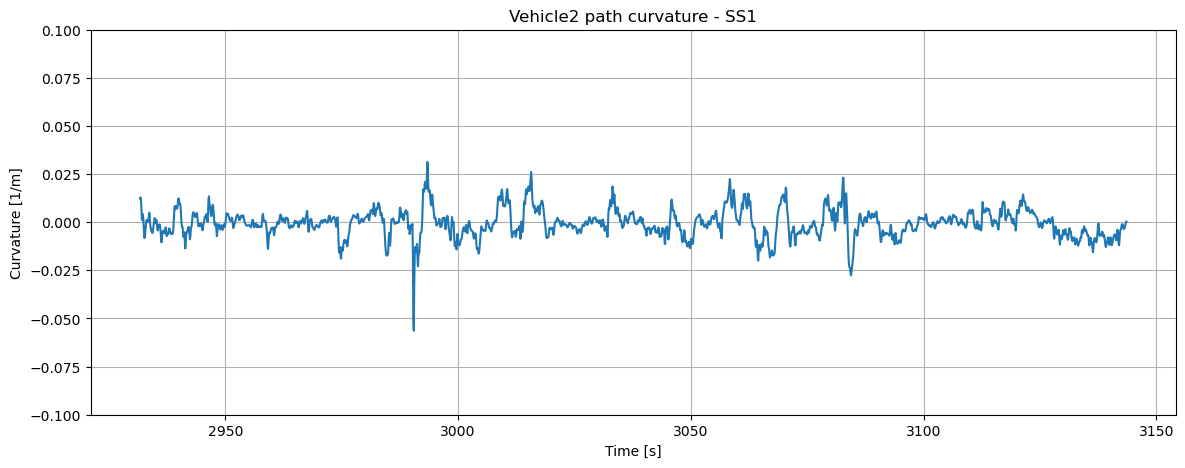

In [43]:
plt.figure(figsize = (14,5))
plt.plot(ss1_v2["time"], ss1_v2["curvature"])

plt.xlabel("Time [s]")
plt.ylabel("Curvature [1/m]")
plt.title("Vehicle2 path curvature - SS1")

plt.ylim(-0.10, 0.10)

plt.grid()
plt.show()

In [44]:
ss1_v2["s"] = calculate_distance(ss1_v2["x"].to_numpy(), ss1_v2["y"].to_numpy())

## Vehicle3

In [45]:
df_3 = pd.read_excel("dev_4_1_combined_66bags_2025-02-23_07-06-25_2025-02-23_08-11-30_CET.xlsx")

In [46]:
data_3 = df_3[["timestamp (1740290785,1740294690) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]", "angular_velocity (-60,60) [掳/s]"]].copy()

In [47]:
data_3["time"] = data_3["timestamp (1740290785,1740294690) [unix]"] - data_3["timestamp (1740290785,1740294690) [unix]"].iloc[0]

In [48]:
ss1_v3 = data_3.loc[35058:37449].copy()

In [49]:
ss1_v3["dt"] = ss1_v3["timestamp (1740290785,1740294690) [unix]"].diff()
ss1_v3["velocity (0,200) [km/h]"] = pd.to_numeric(ss1_v3["velocity (0,200) [km/h]"], errors = "coerce")

In [50]:
"""
print(ss1_v3[[    # no interpolation needed 
    "timestamp (1740290785,1740294690) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss1_v3[[    # no interpolation needed \n    "timestamp (1740290785,1740294690) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [51]:
ss1_v3["velocity (0,200) [km/h]"] = ss1_v3["velocity (0,200) [km/h]"].interpolate()
ss1_v3["velocity_heading (0,360) [掳]"] = ss1_v3["velocity_heading (0,360) [掳]"].interpolate()

In [52]:
ss1_v3["velocity [m/s]"] = ss1_v3["velocity (0,200) [km/h]"] / 3.6 
ss1_v3["velocity_heading (rad)"] = ss1_v3["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [53]:
psi_v3 = ss1_v3["velocity_heading (rad)"]
ss1_v3["v_x"] = ss1_v3["velocity [m/s]"] * np.sin(psi_v3)
ss1_v3["v_y"] = ss1_v3["velocity [m/s]"] * np.cos(psi_v3)

In [54]:
t_v3 = ss1_v3["timestamp (1740290785,1740294690) [unix]"].to_numpy()

ss1_v3["x"] = composite_trapezoidal_rule(t_v3, ss1_v3["v_x"].to_numpy())
ss1_v3["y"] = composite_trapezoidal_rule(t_v3, ss1_v3["v_y"].to_numpy())

## Geometric analysis and curvature - Vehicle3

In [55]:
ss1_v3 = ss1_v3.loc[35058:37097].copy()

In [56]:
print(ss1_v3["dt"].describe())
print(ss1_v3["dt"].round(1).value_counts().sort_index())

count    2039.000000
mean        0.100049
std         0.002215
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max         0.200000
Name: dt, dtype: float64
dt
0.1    2038
0.2       1
Name: count, dtype: int64


In [57]:
t = ss1_v3["timestamp (1740290785,1740294690) [unix]"].to_numpy()
x = ss1_v3["x"].to_numpy()
y = ss1_v3["y"].to_numpy()

In [58]:
ss1_v3["dx_dt"] = central_numerical_differentiation(x, t)
ss1_v3["dy_dt"] = central_numerical_differentiation(y, t)

In [59]:
ss1_v3["velocity_num"] = np.sqrt(ss1_v3["dx_dt"]**2 + ss1_v3["dy_dt"]**2)

ss1_v3["velocity (0,200) [km/h]"] = pd.to_numeric(ss1_v3["velocity (0,200) [km/h]"], errors = "coerce")
print(ss1_v3["velocity (0,200) [km/h]"].isna().sum())

ss1_v3["velocity_ms"] = ss1_v3["velocity (0,200) [km/h]"] / 3.6
ss1_v3["velocity_error"] = (ss1_v3["velocity_num"] - ss1_v3["velocity_ms"])

0


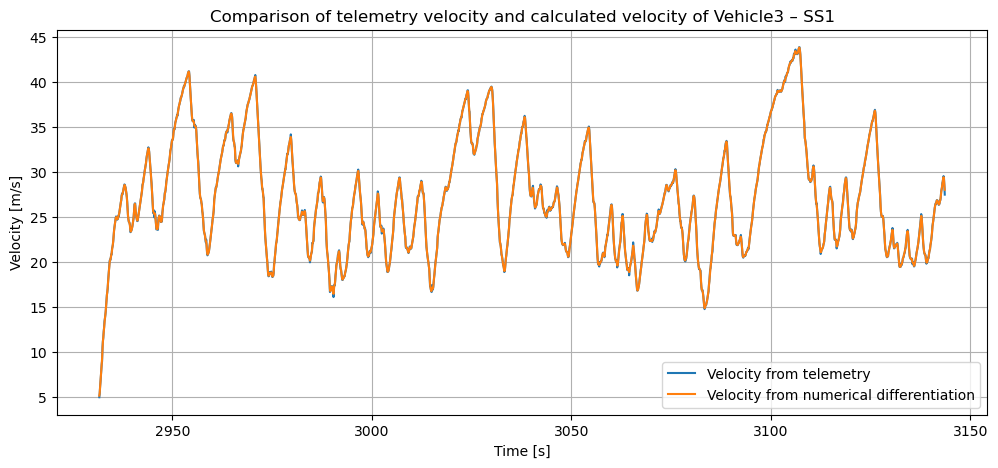

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(ss1_v2["time"], ss1_v2["velocity_ms"], label="Velocity from telemetry")
plt.plot(ss1_v2["time"], ss1_v2["velocity_num"], label="Velocity from numerical differentiation")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Comparison of telemetry velocity and calculated velocity of Vehicle3 – SS1")
plt.legend()
plt.grid()
plt.show()

In [61]:
ss1_v3["dx2_dt2"] = central_numerical_differentiation(ss1_v3["dx_dt"].to_numpy(), t)
ss1_v3["dy2_dt2"] = central_numerical_differentiation(ss1_v3["dy_dt"].to_numpy(), t)

In [62]:
ss1_v3["curvature"] = ((ss1_v3["dx_dt"] * ss1_v3["dy2_dt2"]) - (ss1_v3["dy_dt"] * ss1_v3["dx2_dt2"])) / (ss1_v3["dx_dt"]**2 + ss1_v3["dy_dt"]**2)**(3/2)
ss1_v3["curvature"].describe()

count    2040.000000
mean       -0.000536
std         0.007138
min        -0.052014
25%        -0.004035
50%        -0.000557
75%         0.002737
max         0.031159
Name: curvature, dtype: float64

In [63]:
ss1_v3["abs_curvature"] = ss1_v3["curvature"].abs()
ss1_v3["abs_curvature"].describe()

count    2040.000000
mean        0.005035
std         0.005087
min         0.000002
25%         0.001528
50%         0.003399
75%         0.006968
max         0.052014
Name: abs_curvature, dtype: float64

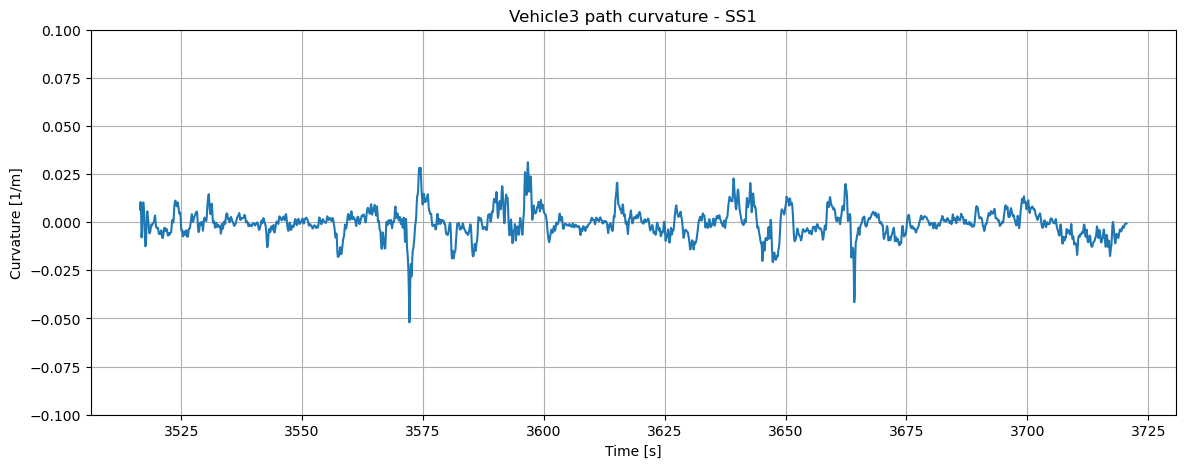

In [64]:
plt.figure(figsize = (14,5))
plt.plot(ss1_v3["time"], ss1_v3["curvature"])

plt.xlabel("Time [s]")
plt.ylabel("Curvature [1/m]")
plt.title("Vehicle3 path curvature - SS1")

plt.ylim(-0.10, 0.10)

plt.grid()
plt.show()

In [65]:
ss1_v3["s"] = calculate_distance(ss1_v3["x"].to_numpy(), ss1_v3["y"].to_numpy())

## Vehicle1, Vehicle2 and Vehicle3 curvature comparison

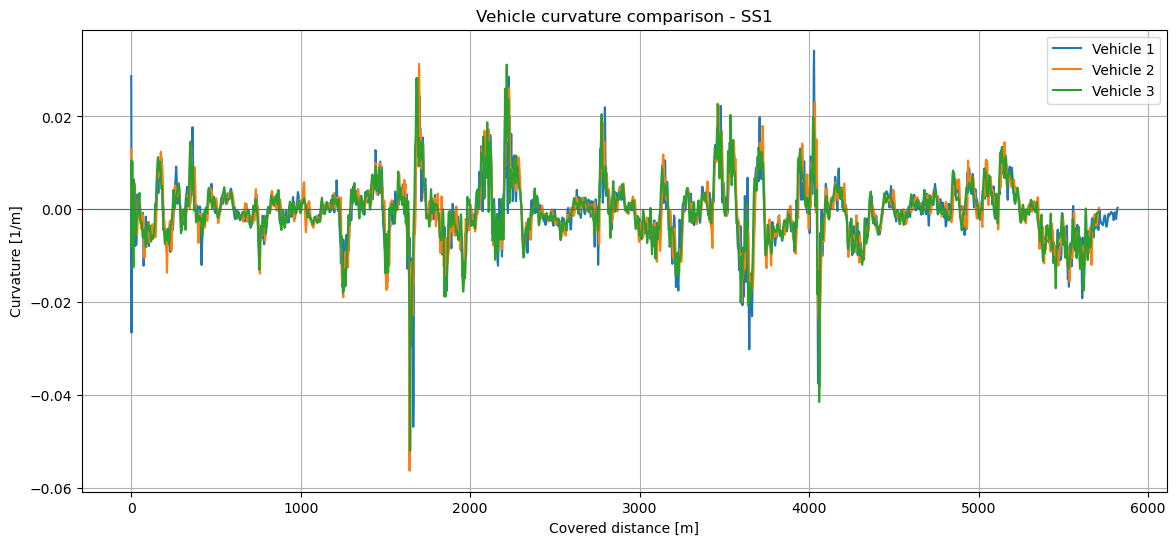

In [66]:
plt.figure(figsize=(14, 6))

plt.plot(ss1["s"], ss1["curvature"], label="Vehicle 1")
plt.plot(ss1_v2["s"], ss1_v2["curvature"], label="Vehicle 2")
plt.plot(ss1_v3["s"], ss1_v3["curvature"], label="Vehicle 3")

plt.axhline(0, linewidth=0.8)

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Vehicle curvature comparison - SS1")
plt.legend()
plt.grid()
plt.show()

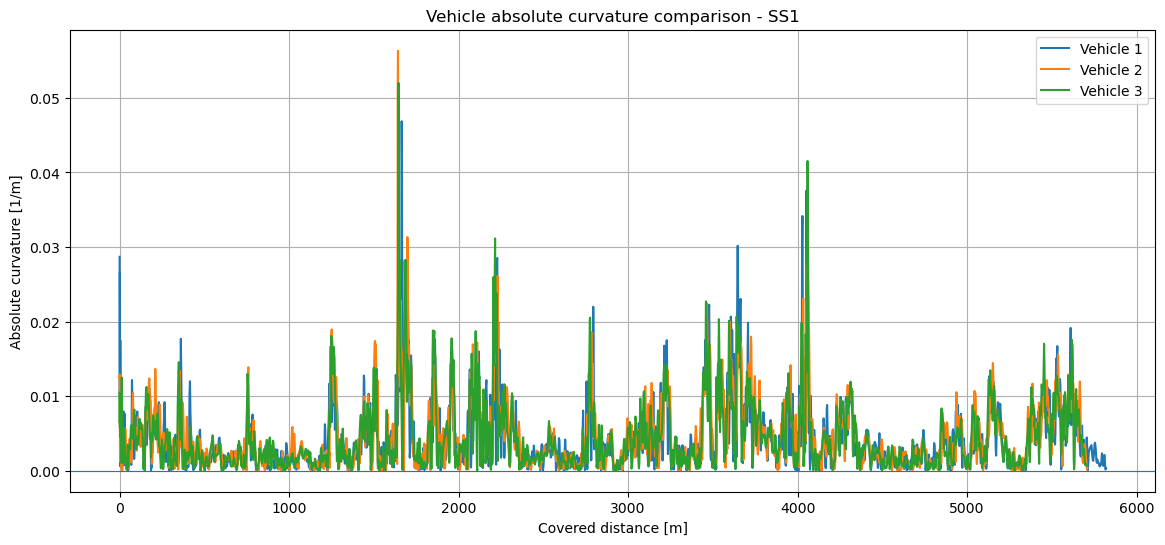

In [67]:
plt.figure(figsize=(14, 6))
ss1_v3["abs_curvature"]

plt.plot(ss1["s"], ss1["abs_curvature"], label="Vehicle 1")
plt.plot(ss1_v2["s"], ss1_v2["abs_curvature"], label="Vehicle 2")
plt.plot(ss1_v3["s"], ss1_v3["abs_curvature"], label="Vehicle 3")

plt.axhline(0, linewidth=0.8)

plt.xlabel("Covered distance [m]")
plt.ylabel("Absolute curvature [1/m]")
plt.title("Vehicle absolute curvature comparison - SS1")
plt.legend()
plt.grid()
plt.show()

## Comparison between "telemetry curvature" and "calculated curvature"

In [68]:
print(ss1["angular_velocity"].isna().sum())
print(ss1_v2["angular_velocity (-60,60) [掳/s]"].isna().sum())
print(ss1_v3["angular_velocity (-60,60) [掳/s]"].isna().sum())

0
0
0


In [69]:
ss1["angular_velocity (rad/s)"] = (ss1["angular_velocity"] * (math.pi / 180))

ss1_v2["angular_velocity (-60,60) [掳/s]"] = pd.to_numeric(ss1_v2["angular_velocity (-60,60) [掳/s]"], errors="coerce")
ss1_v2["angular_velocity (rad/s)"] = (ss1_v2["angular_velocity (-60,60) [掳/s]"] * (math.pi / 180))

ss1_v3["angular_velocity (rad/s)"] = (ss1_v3["angular_velocity (-60,60) [掳/s]"] * (math.pi / 180))

In [70]:
ss1["curvature_telemetry"] = (ss1["angular_velocity (rad/s)"] / ss1["velocity_ms"])
ss1_v2["curvature_telemetry"] = (ss1_v2["angular_velocity (rad/s)"] / ss1_v2["velocity_ms"])
ss1_v3["curvature_telemetry"] = (ss1_v3["angular_velocity (rad/s)"] / ss1_v3["velocity_ms"])

print("V1")
print(ss1["curvature_telemetry"].describe())

print("\nV2")
print(ss1_v2["curvature_telemetry"].describe())

print("\nV3")
print(ss1_v3["curvature_telemetry"].describe())

V1
count    2274.000000
mean        0.000493
std         0.014424
min        -0.086537
25%        -0.007206
50%         0.000216
75%         0.007959
max         0.110329
Name: curvature_telemetry, dtype: float64

V2
count    2119.000000
mean       -0.000285
std         0.011086
min        -0.052227
25%        -0.006699
50%        -0.000202
75%         0.006021
max         0.057024
Name: curvature_telemetry, dtype: float64

V3
count    2040.000000
mean       -0.000122
std         0.027097
min        -0.119470
25%        -0.016985
50%         0.000679
75%         0.016129
max         0.193730
Name: curvature_telemetry, dtype: float64


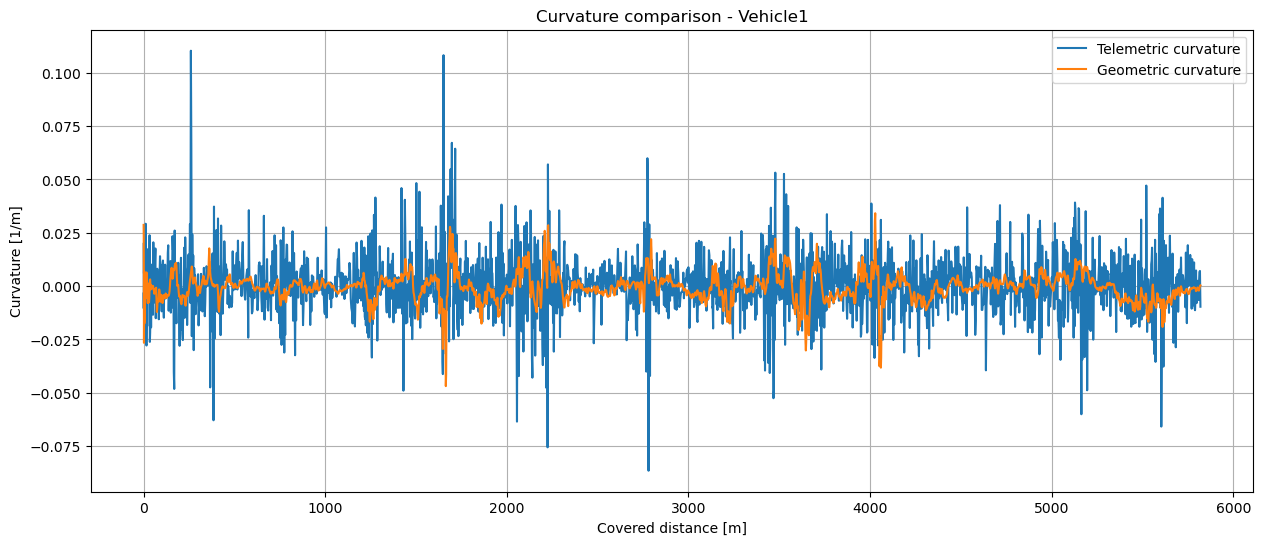

In [71]:
plt.figure(figsize=(15, 6))

plt.plot(ss1["s"], ss1["curvature_telemetry"], label="Telemetric curvature")
plt.plot(ss1["s"], ss1["curvature"], label="Geometric curvature")

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Curvature comparison - Vehicle1")
plt.legend()
plt.grid()
plt.show()

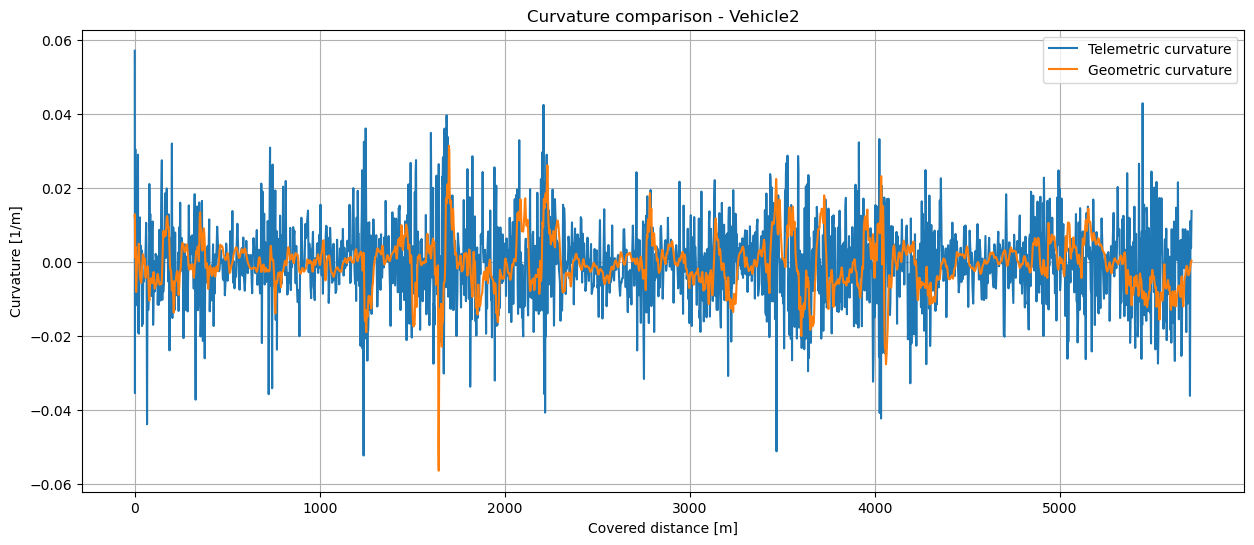

In [72]:
plt.figure(figsize=(15, 6))

plt.plot(ss1_v2["s"], ss1_v2["curvature_telemetry"],label="Telemetric curvature")
plt.plot(ss1_v2["s"], ss1_v2["curvature"], label="Geometric curvature")

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Curvature comparison - Vehicle2")
plt.legend()
plt.grid()
plt.show()

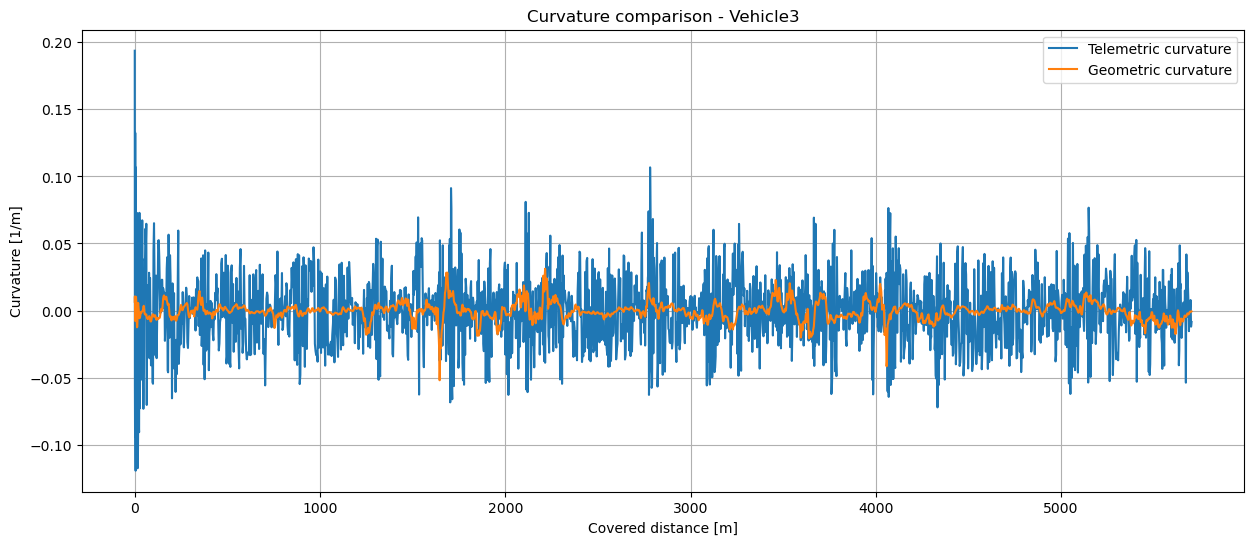

In [73]:
plt.figure(figsize=(15, 6))

plt.plot(ss1_v3["s"], ss1_v3["curvature_telemetry"],label="Telemetric curvature")
plt.plot(ss1_v3["s"], ss1_v3["curvature"], label="Geometric curvature")

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Curvature comparison - Vehicle3")
plt.legend()
plt.grid()
plt.show()

In [74]:
ss1["curvature_telemetry_sg"] = savgol_filter(ss1["curvature_telemetry"], window_length=21, polyorder=2)
ss1_v2["curvature_telemetry_sg"] = savgol_filter(ss1_v2["curvature_telemetry"], window_length=21, polyorder=2)
ss1_v3["curvature_telemetry_sg"] = savgol_filter(ss1_v3["curvature_telemetry"], window_length=21, polyorder=2)

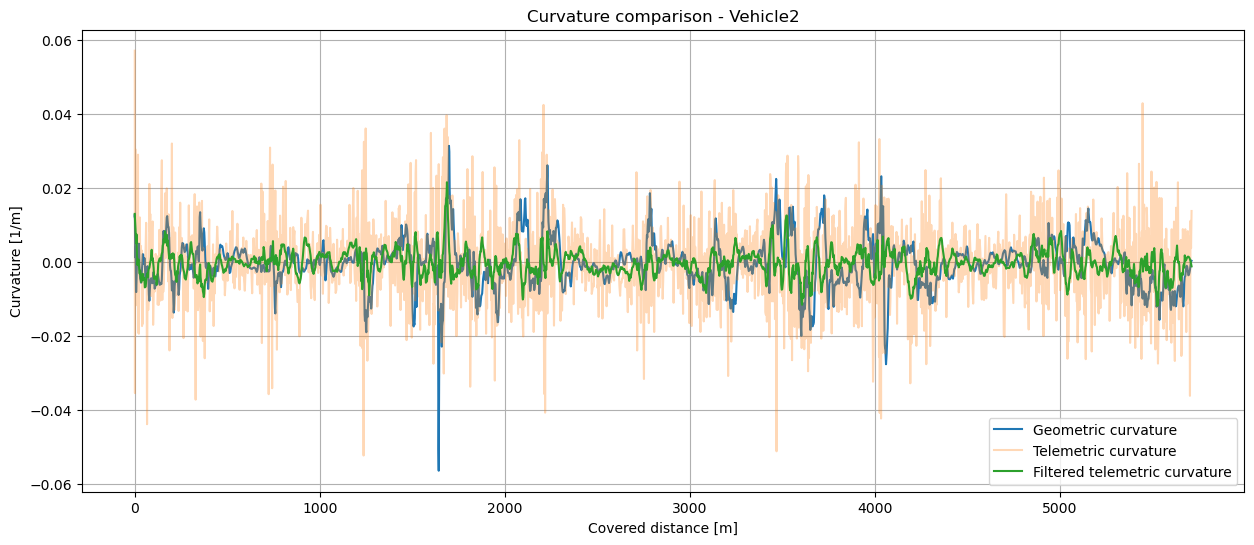

In [75]:
plt.figure(figsize=(15, 6))

plt.plot(ss1_v2["s"], ss1_v2["curvature"], label="Geometric curvature")
plt.plot(ss1_v2["s"], ss1_v2["curvature_telemetry"], label="Telemetric curvature", alpha=0.3)
plt.plot(ss1_v2["s"], ss1_v2["curvature_telemetry_sg"], label="Filtered telemetric curvature")

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Curvature comparison - Vehicle2")
plt.legend()
plt.grid()
plt.show()

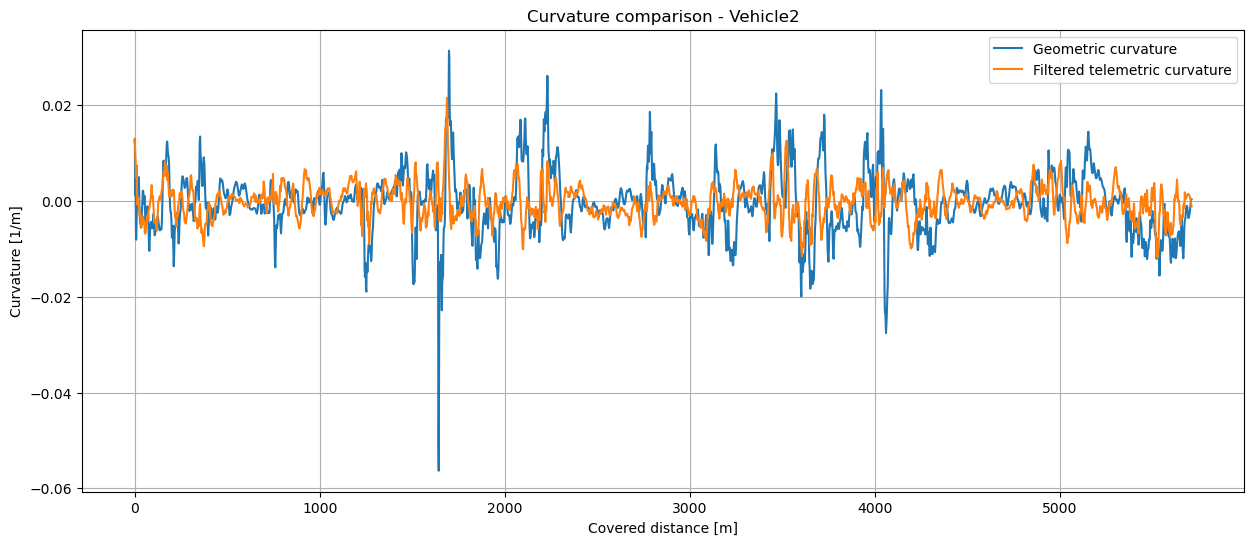

In [76]:
plt.figure(figsize=(15, 6))

plt.plot(ss1_v2["s"], ss1_v2["curvature"], label="Geometric curvature")
plt.plot(ss1_v2["s"], ss1_v2["curvature_telemetry_sg"], label="Filtered telemetric curvature")

plt.xlabel("Covered distance [m]")
plt.ylabel("Curvature [1/m]")
plt.title("Curvature comparison - Vehicle2")
plt.legend()
plt.grid()
plt.show()

In [77]:
vehicles = {"V1": ss1, "V2": ss1_v2, "V3": ss1_v3}
results = []

for name, df in vehicles.items():

    comparison = df[["curvature", "curvature_telemetry"]].dropna()

    correlation = comparison["curvature"].corr(comparison["curvature_telemetry"])
    mae = mean_absolute_error(comparison["curvature"], comparison["curvature_telemetry"])
    rmse = np.sqrt(mean_squared_error(comparison["curvature"], comparison["curvature_telemetry"]))

    results.append({"Vehicle": name, "Correlation": correlation, "MAE [1/m]": mae, "RMSE [1/m]": rmse})

results_df = pd.DataFrame(results)
print(results_df)

  Vehicle  Correlation  MAE [1/m]  RMSE [1/m]
0      V1     0.006468   0.011488    0.016009
1      V2     0.002469   0.009806    0.013160
2      V3    -0.016701   0.021789    0.028132


In [78]:
vehicles = {"V1": ss1, "V2": ss1_v2, "V3": ss1_v3}
results = []

for name, df in vehicles.items():

    comparison = df[["curvature", "curvature_telemetry_sg"]].dropna()

    correlation = comparison["curvature"].corr(comparison["curvature_telemetry_sg"])
    mae = mean_absolute_error(comparison["curvature"], comparison["curvature_telemetry_sg"])

    rmse = np.sqrt(mean_squared_error(comparison["curvature"], comparison["curvature_telemetry_sg"]))

    results.append({"Vehicle": name, "Correlation": correlation, "MAE [1/m]": mae, "RMSE [1/m]": rmse})

results_df = pd.DataFrame(results)
print(results_df)

  Vehicle  Correlation  MAE [1/m]  RMSE [1/m]
0      V1     0.022732   0.006127    0.008396
1      V2     0.144974   0.005492    0.007535
2      V3     0.054713   0.008420    0.011096


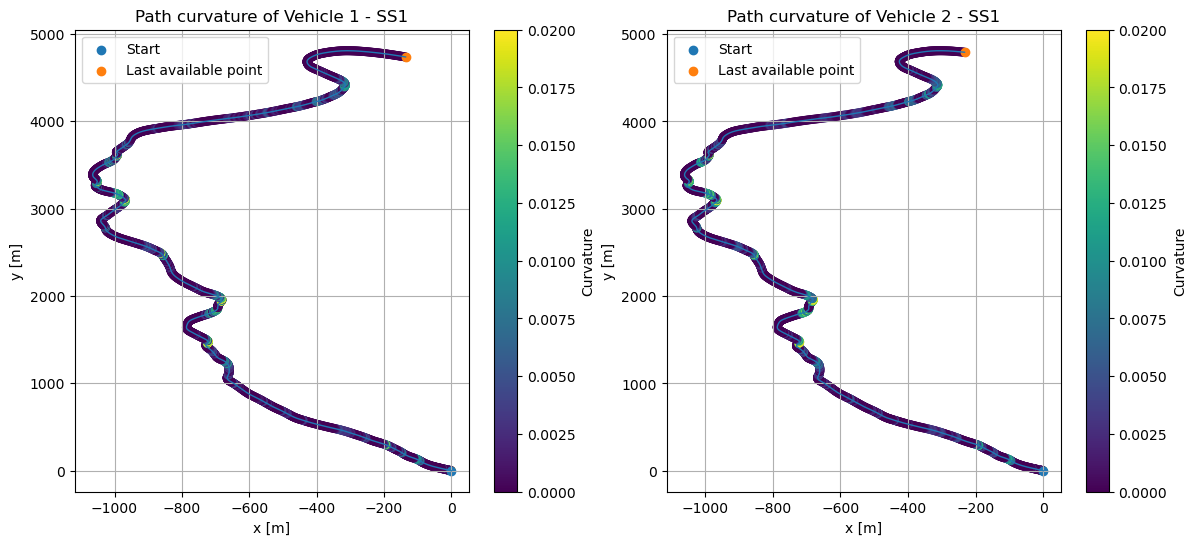

In [94]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss1["x"], ss1["y"], linewidth = 1)

scatter = plt.scatter(ss1["x"], ss1["y"], c=ss1["curvature"], cmap="viridis", vmin = 0, vmax = 0.02, s=30)
plt.colorbar(scatter, label="Curvature")
plt.scatter(ss1["x"].iloc[0], ss1["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss1["x"].iloc[-1], ss1["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Path curvature of Vehicle 1 - SS1")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ss1_v2["x"], ss1_v2["y"], linewidth = 1)

scatter = plt.scatter(ss1_v2["x"], ss1_v2["y"], c=ss1_v2["curvature"], cmap="viridis", vmin = 0, vmax = 0.02, s=30)
plt.colorbar(scatter, label="Curvature")
plt.scatter(ss1_v2["x"].iloc[0], ss1_v2["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss1_v2["x"].iloc[-1], ss1_v2["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Path curvature of Vehicle 2 - SS1")
plt.grid()
plt.legend()

plt.show()


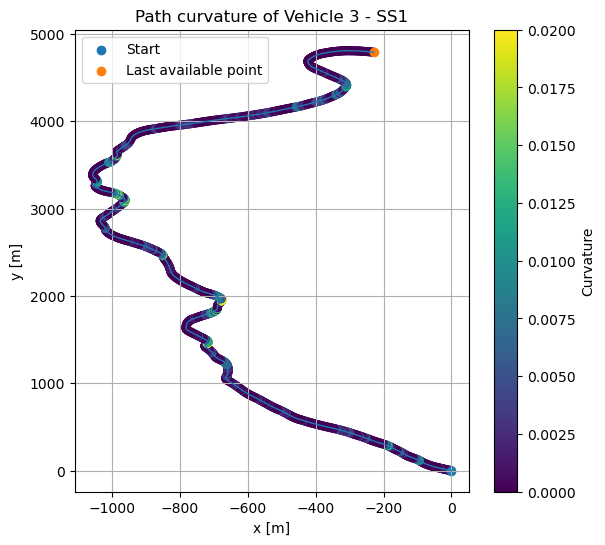

In [95]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss1_v3["x"], ss1_v3["y"], linewidth = 1)

scatter = plt.scatter(ss1_v3["x"], ss1_v3["y"], c=ss1_v3["curvature"], cmap="viridis", vmin = 0, vmax = 0.02, s=30)
plt.colorbar(scatter, label="Curvature")
plt.scatter(ss1_v3["x"].iloc[0], ss1_v3["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss1_v3["x"].iloc[-1], ss1_v3["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Path curvature of Vehicle 3 - SS1")
plt.grid()
plt.legend()

plt.show()
